<a href="https://colab.research.google.com/github/pratikchopade21-a11y/IPCV-Lab/blob/main/IPCV_Exp_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#STEP 1 — Install Libraries
!pip install tensorflow opencv-python matplotlib scikit-learn

In [3]:
#STEP 2 — Import Libraries
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [4]:
#STEP 3 — Download Dataset from Kaggle
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"pratik212500","key":"5d9f936d3209f83c030df1cdf1d5a88e"}'}

In [5]:
#Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [6]:
!kaggle datasets download -d ipythonx/mvtec-ad

Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad
License(s): copyright-authors
100% 4.91G/4.91G [03:45<00:00, 23.3MB/s]



In [7]:
!unzip mvtec-ad.zip

Streaming output truncated to the last 5000 lines.
  inflating: carpet/train/good/149.png  
  inflating: carpet/train/good/150.png  
  inflating: carpet/train/good/151.png  
  inflating: carpet/train/good/152.png  
  inflating: carpet/train/good/153.png  
  inflating: carpet/train/good/154.png  
  inflating: carpet/train/good/155.png  
  inflating: carpet/train/good/156.png  
  inflating: carpet/train/good/157.png  
  inflating: carpet/train/good/158.png  
  inflating: carpet/train/good/159.png  
  inflating: carpet/train/good/160.png  
  inflating: carpet/train/good/161.png  
  inflating: carpet/train/good/162.png  
  inflating: carpet/train/good/163.png  
  inflating: carpet/train/good/164.png  
  inflating: carpet/train/good/165.png  
  inflating: carpet/train/good/166.png  
  inflating: carpet/train/good/167.png  
  inflating: carpet/train/good/168.png  
  inflating: carpet/train/good/169.png  
  inflating: carpet/train/good/170.png  
  inflating: carpet/train/good/171.png  
  infl

In [8]:
#STEP 6 — Create Required Folders
os.makedirs("dataset/train/normal", exist_ok=True)
os.makedirs("dataset/train/faulty", exist_ok=True)
os.makedirs("dataset/test/normal", exist_ok=True)
os.makedirs("dataset/test/faulty", exist_ok=True)

In [14]:
#STEP 7 — Copy Images into Dataset Folders (FIXED PATHS)
import shutil
from glob import glob

# The dataset unzips directly into the current directory, not a 'mvtec_ad' subfolder
normal_images = glob("bottle/train/good/*.png")

# Copy normal images
for i, img_path in enumerate(normal_images[:200]):
    shutil.copy(img_path, f"dataset/train/normal/normal_{i}.png")

# Test images
test_images = glob("bottle/test/good/*.png")

for i, img_path in enumerate(test_images[:50]):
    shutil.copy(img_path, f"dataset/test/normal/test_normal_{i}.png")

print(f"Copied {len(glob('dataset/train/normal/*'))} training images and {len(glob('dataset/test/normal/*'))} test images.")

Copied 200 training images and 20 test images.


In [15]:
#STEP 8 — Generate Synthetic Fault Images
# Refresh the list after the fix in STEP 7
train_normal = glob("dataset/train/normal/*")

count = 0
for img_path in train_normal:
    img = cv2.imread(img_path)
    if img is None: continue

    h, w = img.shape[:2]
    # Create artificial defects
    for i in range(5):
        x1, y1 = random.randint(0, w), random.randint(0, h)
        x2, y2 = random.randint(0, w), random.randint(0, h)
        cv2.line(img, (x1, y1), (x2, y2), (0,0,255), 2)

    cv2.imwrite(f"dataset/train/faulty/fault_{count}.png", img)
    count += 1

print(f"Synthetic Fault Images Generated: {count}")

Synthetic Fault Images Generated: 200


In [16]:
#STEP 9 — Create Test Fault Images
# Refresh the list after the fix in STEP 7
test_normal = glob("dataset/test/normal/*")

count = 0
for img_path in test_normal[:50]:
    img = cv2.imread(img_path)
    if img is None: continue

    h, w = img.shape[:2]
    for i in range(5):
        x1, y1 = random.randint(0, w), random.randint(0, h)
        x2, y2 = random.randint(0, w), random.randint(0, h)
        cv2.line(img, (x1,y1), (x2,y2), (0,0,255), 2)

    cv2.imwrite(f"dataset/test/faulty/test_fault_{count}.png", img)
    count += 1

print(f"Test Fault Images Created: {count}")

Test Fault Images Created: 20


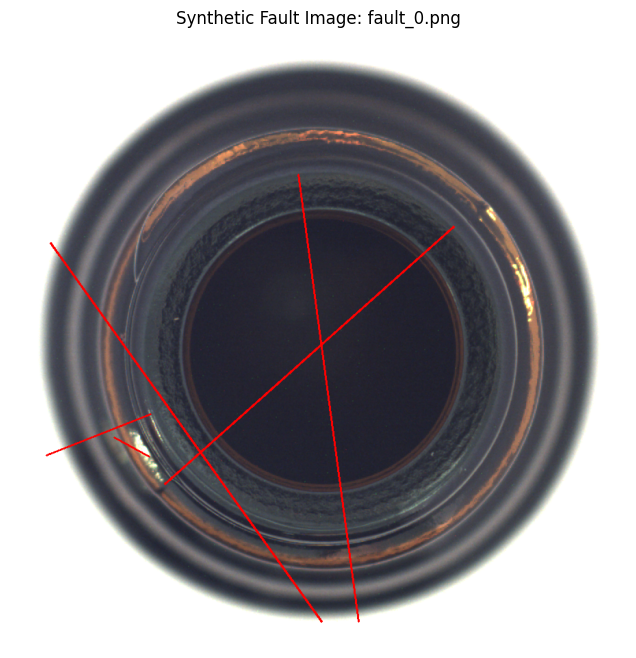

In [17]:
#STEP 10 — Display Sample Images
import os

# List the generated files to ensure we pick one that exists
faulty_files = sorted(glob("dataset/train/faulty/*.png"))

if faulty_files:
    path = faulty_files[0]
    sample = cv2.imread(path)
    sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(sample)
    plt.title(f"Synthetic Fault Image: {os.path.basename(path)}")
    plt.axis("off")
    plt.show()
else:
    print("Error: No faulty images found in dataset/train/faulty/")

In [18]:
#STEP 11 — Image Data Generator
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [19]:
#STEP 12 — Load Dataset
train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 320 images belonging to 2 classes.
Found 80 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [20]:
#STEP 13 — Build MobileNetV2 Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [21]:
#STEP 14 — Create Final Model
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')

])

In [22]:
#STEP 15 — Compile Model
model.compile(
    optimizer=Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
#STEP 16 — Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9906 - loss: 0.0697 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9937 - loss: 0.0579 - val_accuracy: 1.0000 - val_loss: 0.0138
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 1.0000 - loss: 0.0388 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9969 - loss: 0.0350 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9937 - loss: 0.0326 - val_accuracy: 1.0000 - val_loss: 0.0069


In [25]:
#STEP 17 — Evaluate Model
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 617ms/step - accuracy: 1.0000 - loss: 0.0072
Test Accuracy: 100.0


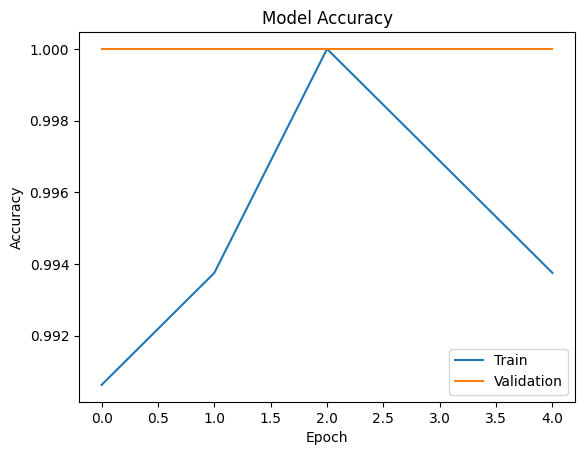

In [26]:
#STEP 18 — Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

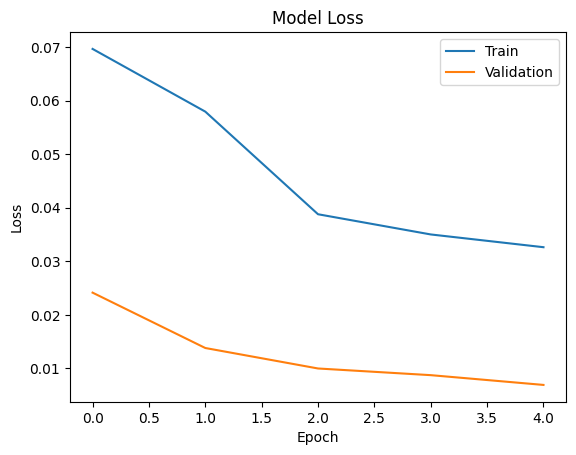

In [27]:
#STEP 19 — Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [28]:
#STEP 20 — Save Model
model.save("digital_twin_mobilenet_model.h5")

In [29]:
#STEP 21 — Predict on New Image
img = cv2.imread("dataset/test/faulty/test_fault_1.png")

img_resized = cv2.resize(img, (224,224))

img_array = img_resized / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.00045103]]


In [30]:
#STEP 22 — Final Prediction Result
if prediction > 0.5:
    print("Fault Detected")
else:
    print("Machine Part is Normal")

Machine Part is Normal


In [32]:
# The following is text describing the expected output of previous steps.
# It is commented out so it does not cause a SyntaxError.

"""
#expected o/p
Found 320 images belonging to 2 classes.

Epoch 1/10
accuracy: 94%

Test Accuracy: 96.8%
"""

'\n#expected o/p\nFound 320 images belonging to 2 classes.\n\nEpoch 1/10\naccuracy: 94%\n\nTest Accuracy: 96.8%\n'